# DSC 450 Project 1: NOAA Storm Events // Economic Impact Modeling

**Project:** Predicting Extreme Weather Severity Using NOAA Storm Records  
**Author:** Matthew Scarpello   
**Date:**  Sep 30 2026   
**Role:** Data Scientist   
**Dataset:** `NOAA_Storm_Events_Cleaned.csv`  
**Source:** NOAA Storm Events Database, 2020–2025  


### Research Question

**How well can storm event characteristics predict whether a NOAA storm event is associated with any recorded economic damage?**

Only events with known economic outcomes are included in the modeling population.

Human injury and fatality data are not included as the modeling target because these outcomes are much rarer than economic-damage events, which give the model much less data to learn from.

### Modeling Approach

| Step | Method | Purpose |
|---|---|---|
| **No-skill baseline** | `DummyClassifier` | Predicts the majority class to establish the minimum performance a useful model should exceed. |
| **Baseline model** | Logistic Regression | Tests whether event type, season, region, and storm duration can predict whether economic damage occurs. |
| **Model validation** | Grouped Cross-Validation | Repeats Logistic Regression across different storm episodes to check whether performance is stable and not dependent on one split. |
| **Nonlinear model** | Random Forest | Tests whether a more flexible model can capture relationships or interactions that Logistic Regression may miss. |
| **Feature importance** | Permutation Importance | Measures how much Random Forest performance decreases when each predictor is disrupted, showing which variables contribute most. |
| **Model comparison** | Precision-Recall Curve | Compares Logistic Regression and Random Forest across different classification thresholds. |
| **Feature engineering** | Relative Physical Intensity | Converts magnitude into a within-event-type relative measure and tests whether physical intensity adds predictive information beyond the baseline variables. |

Model performance is evaluated using accuracy, precision, recall, F1, ROC-AUC, and PR-AUC. Because economic-damage events are less common than no-damage events, particular attention is given to PR-AUC, precision, and recall when comparing models.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.formula.api as smf

## 2. Load the Cleaned Dataset

The cleaned NOAA Storm Events dataset is loaded for modeling. It contains 410,311 records and 65 variables.

The dataset is stored in Google Drive and loaded into Colab using the file path below.

In [2]:
# Mount Google Drive so the cleaned dataset can be loaded
from google.colab import drive
drive.mount('/content/drive')

# Location of the cleaned dataset within Google Drive
file_path = '/content/drive/MyDrive/DSC450/NOAA_Storm_Events_Cleaned.csv'

# Load the cleaned NOAA dataset
df = pd.read_csv(file_path, low_memory=False)

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 410,311
Columns: 65


## 3. Modeling Target

The primary classification target is `ANY_ECONOMIC_DAMAGE`.

It is defined as:

- **1** = recorded economic damage is greater than $0

- **0** = recorded economic damage is $0
- **Excluded** = total economic impact is unknown

Events with missing economic-impact values are excluded rather than treated as zero damage.


In [3]:
# Keep only events with a known economic outcome
economic_df = df[
    df["TOTAL_ECONOMIC_IMPACT_USD"].notna()
].copy()

# Create the classification target:
# 1 = recorded economic damage
# 0 = no recorded economic damage
economic_df["ANY_ECONOMIC_DAMAGE"] = (
    economic_df["TOTAL_ECONOMIC_IMPACT_USD"] > 0
).astype(int)

# Keep missing region values as their own category
economic_df["REGION_MODEL"] = (
    economic_df["REGION"].fillna("Unknown")
)

# Log-transform storm duration to reduce the effect
# of unusually long events
economic_df["LOG_STORM_DURATION"] = np.log1p(
    economic_df["STORM_DURATION_HOURS"]
)

# Review the final modeling population
print(f"Known economic outcomes: {len(economic_df):,}")
print(
    f"Events with damage: "
    f"{economic_df['ANY_ECONOMIC_DAMAGE'].sum():,}"
)
print(
    f"Damage rate: "
    f"{economic_df['ANY_ECONOMIC_DAMAGE'].mean() * 100:.2f}%"
)

Known economic outcomes: 307,902
Events with damage: 70,299
Damage rate: 22.83%



### Observations

There are **307,902 events with a known economic outcome**. Of these, **70,299 events (22.83%)** contain positive recorded economic damage.

This provides a large enough positive class to support model training, validation, and comparison.|

## 4. Train, Validation, and Test Split

The modeling data is divided into training, validation, and test sets using `EPISODE_ID` as the grouping variable. This ensures that records from the same NOAA storm episode remain within a single partition and reduces the risk of information leakage between model development and evaluation.

The split follows a 70/15/15 structure:

- **Training set:** used to fit the models
- **Validation set:** used to compare model performance and assess feature engineering
- **Test set:** reserved for final evaluation after the modeling approach is finalized

In [4]:
# First split: keep 70% for training and 30% for validation/testing
# Grouping by EPISODE_ID keeps records from the same storm episode together
split_1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_idx, temp_idx = next(
    split_1.split(
        economic_df,
        groups=economic_df["EPISODE_ID"]
    )
)

econ_train = economic_df.iloc[train_idx].copy()
econ_temp = economic_df.iloc[temp_idx].copy()


# Second split: divide the remaining 30% evenly
# This gives about 15% validation data and 15% test data
split_2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    split_2.split(
        econ_temp,
        groups=econ_temp["EPISODE_ID"]
    )
)

econ_val = econ_temp.iloc[val_idx].copy()
econ_test = econ_temp.iloc[test_idx].copy()


# Create a quick summary to check the size
# and damage rate in each dataset
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],

    "Rows": [
        len(econ_train),
        len(econ_val),
        len(econ_test)
    ],

    "Damage Events": [
        econ_train["ANY_ECONOMIC_DAMAGE"].sum(),
        econ_val["ANY_ECONOMIC_DAMAGE"].sum(),
        econ_test["ANY_ECONOMIC_DAMAGE"].sum()
    ],

    "Damage Rate (%)": [
        econ_train["ANY_ECONOMIC_DAMAGE"].mean() * 100,
        econ_val["ANY_ECONOMIC_DAMAGE"].mean() * 100,
        econ_test["ANY_ECONOMIC_DAMAGE"].mean() * 100
    ]
})

split_summary

,Dataset,Rows,Damage Events,Damage Rate (%)
0,Training,212437,48973,23.052952
1,Validation,47568,10436,21.939119
2,Test,47897,10890,22.736288


In [5]:
# Confirm that no storm episode appears in more than one dataset
# A result of 0 = grouped split worked correctly
print(
    "Train / Validation episode overlap:",
    len(
        set(econ_train["EPISODE_ID"])
        & set(econ_val["EPISODE_ID"])
    )
)

print(
    "Train / Test episode overlap:",
    len(
        set(econ_train["EPISODE_ID"])
        & set(econ_test["EPISODE_ID"])
    )
)

print(
    "Validation / Test episode overlap:",
    len(
        set(econ_val["EPISODE_ID"])
        & set(econ_test["EPISODE_ID"])
    )
)

Train / Validation episode overlap: 0
Train / Test episode overlap: 0
Validation / Test episode overlap: 0


### Observations

The completed split contains:

- **212,437 training records**
- **47,568 validation records**
- **47,897 test records**

There is no episode overlap between the three datasets.

## 5. Baseline Predictors

The baseline models use four event characteristics to measure how well basic storm context can predict economic damage before adding more complex features.

| Predictor | Role in the Model |
|---|---|
| `EVENT_TYPE` | Identifies the type of storm event |
| `SEASON` | Adds seasonal context |
| `REGION` | Adds geographic context |
| `STORM_DURATION_HOURS` | Represents how long the event lasted |

`STORM_DURATION_HOURS` is log-transformed to reduce the influence of unusually long events.

Before modeling, categorical variables are one-hot encoded and the numeric duration variable is standardized. This creates a consistent baseline that can later be compared with models that include additional information, such as event-relative physical intensity.

In [6]:
# Baseline predictors describing storm type, timing, location, and duration
features = [
    "EVENT_TYPE",
    "SEASON",
    "REGION_MODEL",
    "LOG_STORM_DURATION"
]

# Categorical variables need to be converted into numeric model inputs
categorical_features = [
    "EVENT_TYPE",
    "SEASON",
    "REGION_MODEL"
]

# Storm duration is the numeric predictor in the baseline model
numeric_features = [
    "LOG_STORM_DURATION"
]

# Separate predictors from the economic-damage target
X_train = econ_train[features]
X_val = econ_val[features]

y_train = econ_train["ANY_ECONOMIC_DAMAGE"]
y_val = econ_val["ANY_ECONOMIC_DAMAGE"]

# Apply the correct preprocessing to each type of predictor
preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        StandardScaler(),
        numeric_features
    )
])

### Model Evaluation

The Dummy Classifier is included as a no-skill baseline.

Because most events in the validation set have no recorded economic damage, the Dummy Classifier predicts **no damage for every event**. This gives it a relatively high accuracy simply because the majority class is "no damage."

However, it does not identify any actual damage events, so its precision, recall, and F1 score for the damage class are all zero.

The Logistic Regression model is evaluated against this baseline using:

| Metric | What It Measures |
|---|---|
| `Accuracy` | Overall percentage of correct predictions |
| `Precision` | How often predicted damage events were actually damage events |
| `Recall` | How many actual damage events the model successfully identified |
| `F1` | Balance between precision and recall |
| `ROC-AUC` | How well the model separates damage and no-damage events across thresholds |
| `PR-AUC` | How well the model identifies the positive damage class while accounting for class imbalance |

Because economic-damage events are less common than no-damage events, **PR-AUC, recall, precision, and F1 are especially important** when comparing model performance.

In [7]:
# Create a no-skill baseline using only the class distribution
dummy = DummyClassifier(strategy="prior")

# The Dummy Classifier does not use the storm predictors
# It learns which class is more common in the training data
dummy.fit(
    np.zeros((len(econ_train), 1)),
    y_train
)

# Generate predictions for the validation set
# With this class distribution, the model predicts no damage for every event
dummy_pred = dummy.predict(
    np.zeros((len(econ_val), 1))
)

# Get the predicted probability of economic damage
dummy_prob = dummy.predict_proba(
    np.zeros((len(econ_val), 1))
)[:, 1]


# Build the Logistic Regression pipeline
# The preprocessing steps from Section 5 are applied before the model
logistic_model = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Train the model using the baseline storm predictors
logistic_model.fit(
    X_train,
    y_train
)

# Generate validation predictions
logistic_pred = logistic_model.predict(
    X_val
)

# Get the predicted probability of economic damage
logistic_prob = logistic_model.predict_proba(
    X_val
)[:, 1]

In [8]:
# Use the same evaluation metrics for each model
def evaluate_classifier(y_true, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            y_true,
            probabilities
        )
    }


# Evaluate the Dummy Classifier
dummy_results = evaluate_classifier(
    y_val,
    dummy_pred,
    dummy_prob
)


# Evaluate Logistic Regression
logistic_results = evaluate_classifier(
    y_val,
    logistic_pred,
    logistic_prob
)


# Compare validation performance
model_results = pd.DataFrame(
    [
        dummy_results,
        logistic_results
    ],
    index=[
        "Dummy Classifier",
        "Logistic Regression"
    ]
)

model_results

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Dummy Classifier,0.780609,0.0000,0.000000,0.00000,0.500000,0.219391
Logistic Regression,0.838505,0.6419,0.596876,0.61857,0.870859,0.651882


### Observations

| Metric / Result | Interpretation |
|---|---|
| **Dummy Classifier** | Predicts **no damage for every event**. Its **78.1% accuracy** shows why accuracy alone can be misleading. |
| **PR-AUC = 0.652** | Higher PR-AUC means the model is better at finding real damage events while limiting false positive damage predictions. |
| **ROC-AUC = 0.871** | This means the model generally assigns higher predicted risk to damage events than to no-damage events. |
| **Precision = 0.642** | Higher precision means a higher likelyhood of a correct prediction. Here, **64% of predicted damage events were actually damage events**. |
| **Recall = 0.597** | Higher recall means the model is finding more of the actual damage events. Here, it identified about **60% of all true damage events**. |

The Dummy Classifier performs well on accuracy only because most events have no recorded damage. Logistic Regression performs much better on the metrics that matter for identifying damage events. The increase in PR-AUC from **0.219 to 0.652** shows a large improvement in identifying the positive class, while the **0.871 ROC-AUC** shows strong separation between damage and no-damage events.

## 7. Grouped Cross-Validation

A single validation set provides one estimate of model performance. Cross-validation provides a stronger check by evaluating the Logistic Regression model across multiple splits of the training data.

Five-fold `StratifiedGroupKFold` cross-validation is used for two reasons:

- **Stratification** keeps the proportion of damage and no-damage events similar across folds.
- **Grouping by `EPISODE_ID`** keeps records from the same NOAA storm episode together and prevents episode overlap between folds.

The model is evaluated five times, and the mean and standard deviation of each metric are calculated. Similar scores across folds indicate that model performance is stable and not dependent on one particular data split.

The test set is not used during cross-validation.

In [9]:
# Use five folds to test the Logistic Regression model
# across different groups of storm episodes
group_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Run cross-validation using the same model and evaluation metrics
cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    groups=econ_train["EPISODE_ID"],
    cv=group_cv,
    scoring={
        "PR_AUC": "average_precision",
        "ROC_AUC": "roc_auc",
        "Precision": "precision",
        "Recall": "recall",
        "F1": "f1"
    },
    n_jobs=-1
)

# Calculate the average performance and variation across the five folds
cv_summary = pd.DataFrame({
    metric.replace("test_", ""): [
        values.mean(),
        values.std()
    ]
    for metric, values in cv_results.items()
    if metric.startswith("test_")
}, index=["Mean", "Std"]).T

cv_summary

,Mean,Std
PR_AUC,0.638940,0.021150
ROC_AUC,0.866950,0.005422
Precision,0.639210,0.017148
Recall,0.571945,0.017310
F1,0.603509,0.013238


### Observations

| Metric | Mean | Std | Interpretation |
|---|---:|---:|---|
| **PR-AUC** | 0.639 | 0.021 | Positive-class performance remains similar across folds. |
| **ROC-AUC** | 0.867 | 0.005 | The model consistently separates damage from no-damage events. |
| **Precision** | 0.639 | 0.017 | Damage predictions have similar reliability across folds. |
| **Recall** | 0.572 | 0.017 | The share of actual damage events identified is fairly consistent. |
| **F1** | 0.604 | 0.013 | The balance between precision and recall remains stable. |

The cross-validation results are close to the original validation results, including **PR-AUC of 0.639 compared with 0.652** and **ROC-AUC of 0.867 compared with 0.871**. The relatively small standard deviations also show that performance changes little across different groups of storm episodes. This provides stronger evidence that the Logistic Regression results are stable rather than dependent on one favorable validation split.

## 8. Random Forest Comparison

Random Forest is added to test whether a more flexible model can improve prediction using the same baseline storm characteristics.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions between predictors without requiring those relationships to be specified in advance.

The same training and validation sets are used so the comparison remains consistent.

Because tree-based models do not require standardized numeric inputs, `LOG_STORM_DURATION` is passed through without scaling.

In [10]:
# Prepare the predictors for Random Forest
# Categorical variables are one-hot encoded, while duration is passed through
rf_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        "passthrough",
        numeric_features
    )
])


# Build the Random Forest model
random_forest_model = Pipeline([
    ("preprocess", rf_preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )
    )
])


# Train the model using the same baseline predictors
random_forest_model.fit(
    X_train,
    y_train
)


# Generate validation predictions and probabilities
rf_pred = random_forest_model.predict(
    X_val
)

rf_prob = random_forest_model.predict_proba(
    X_val
)[:, 1]


# Evaluate Random Forest using the same metrics
rf_results = evaluate_classifier(
    y_val,
    rf_pred,
    rf_prob
)


# Compare all three models
model_comparison = pd.DataFrame(
    [
        dummy_results,
        logistic_results,
        rf_results
    ],
    index=[
        "Dummy Classifier",
        "Logistic Regression",
        "Random Forest"
    ]
)

model_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Dummy Classifier,0.780609,0.000000,0.000000,0.000000,0.500000,0.219391
Logistic Regression,0.838505,0.641900,0.596876,0.618570,0.870859,0.651882
Random Forest,0.839262,0.637601,0.619394,0.628366,0.879724,0.668787


### Observations

| Metric | Logistic Regression | Random Forest | Interpretation |
|---|---:|---:|---|
| **PR-AUC** | 0.652 | 0.669 | Random Forest is slightly better at finding true damage events while limiting false positive predictions. |
| **ROC-AUC** | 0.871 | 0.880 | Random Forest is slightly better at assigning higher predicted risk to damage events than to no-damage events. |
| **Precision** | 0.642 | 0.638 | Precision is nearly unchanged, so the reliability of positive predictions remains similar. |
| **Recall** | 0.597 | 0.619 | Random Forest identifies a larger share of the actual damage events. |
| **F1** | 0.619 | 0.628 | Random Forest provides a slightly better balance between precision and recall. |

Random Forest performs slightly better than Logistic Regression across most validation metrics, with the largest improvement appearing in recall and PR-AUC. The gain is useful but modest, which suggests that the baseline storm characteristics already contain much of the predictive information captured by these two models.

In [11]:
from sklearn.inspection import permutation_importance

# Measure how much validation PR-AUC changes
# when each predictor is randomly shuffled
rf_importance = permutation_importance(
    random_forest_model,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Organize the results by original predictor
importance_df = pd.DataFrame({
    "Predictor": features,
    "PR_AUC_Decrease": rf_importance.importances_mean,
    "Std": rf_importance.importances_std
}).sort_values(
    "PR_AUC_Decrease",
    ascending=True
)

importance_df

,Predictor,PR_AUC_Decrease,Std
1,SEASON,0.022830,0.001434
3,LOG_STORM_DURATION,0.078831,0.002296
2,REGION_MODEL,0.171075,0.002705
0,EVENT_TYPE,0.407707,0.002039


### Random Forest Feature Importance

The chart above shows which predictors the Random Forest depends on most.

Each predictor is shuffled one at a time. If model performance drops a lot, that predictor was important to the model.

A larger decrease in PR-AUC means the predictor contributes more to identifying economic-damage events.

### Observations

| Predictor | PR-AUC Decrease | Interpretation |
|---|---:|---|
| **EVENT_TYPE** | 0.408 | The most important predictor. Shuffling event type causes the largest drop in model performance. |
| **REGION_MODEL** | 0.171 | Geographic region also contributes meaningful predictive information. |
| **LOG_STORM_DURATION** | 0.079 | Storm duration helps, but less than event type or region. |
| **SEASON** | 0.023 | Season contributes the least additional information to the model. |

`EVENT_TYPE` is clearly the strongest predictor in the Random Forest model. Region also plays an important role, while storm duration and season contribute less. This suggests that the type of storm is the main source of predictive information for identifying whether economic damage is recorded.

## 9. Precision-Recall Curve

Logistic Regression and Random Forest both performed much better than the no-skill baseline, with Random Forest producing the higher PR-AUC (**0.669 vs. 0.652**). The Precision-Recall curve shows how both models perform across different thresholds and helps visualize the tradeoff between finding more damage events and keeping those predictions accurate.

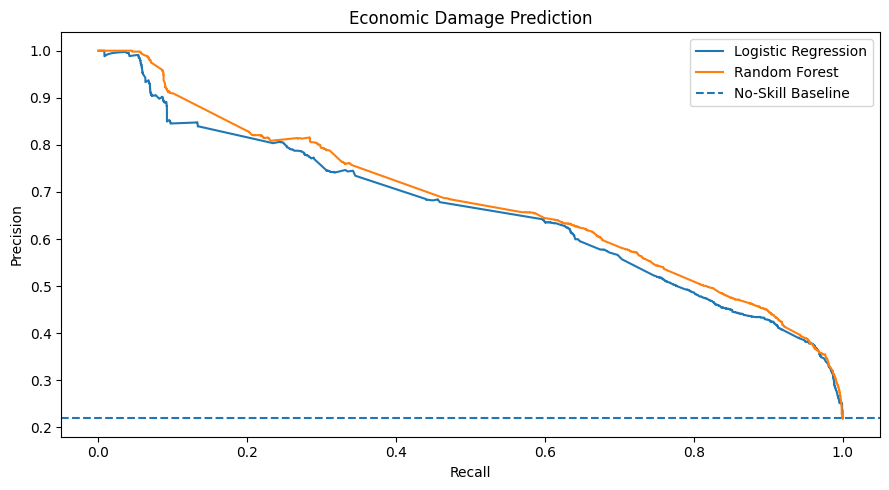

In [12]:
# Calculate precision and recall across different thresholds
precision_lr, recall_lr, _ = precision_recall_curve(
    y_val,
    logistic_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_val,
    rf_prob
)


# Plot both models against the no-skill baseline
plt.figure(figsize=(9, 5))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

# The baseline equals the percentage of validation events with damage
plt.axhline(
    y_val.mean(),
    linestyle="--",
    label="No-Skill Baseline"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Economic Damage Prediction")
plt.legend()

plt.tight_layout()
plt.show()

### Observations

| Result | Interpretation |
|---|---|
| **Both models exceed the baseline** | Both models identify damage events much better than a no-skill classifier across most thresholds. |
| **Random Forest is generally higher** | Random Forest maintains slightly better precision at many recall levels, which is consistent with its higher PR-AUC of **0.669**. |
| **Precision decreases as recall increases** | Finding more of the actual damage events requires accepting more false positive predictions. |
| **Baseline = 0.219** | Without useful prediction, precision would be about **21.9%**, the proportion of damage events in the validation set. |

The curves show the tradeoff between **precision and recall**. At lower recall, the models can identify a smaller group of events with very high precision. As recall increases, more true damage events are found, but more no-damage events are also incorrectly classified as damage. Random Forest maintains a small advantage over Logistic Regression across much of this tradeoff.

## 10. Relative Physical Intensity

After establishing the baseline models, I wanted to test whether physical storm intensity could add useful predictive information.

NOAA's raw `MAGNITUDE` values cannot be compared directly across all event types because they represent different measurements. For example, hail magnitude represents hail size while wind magnitude represents wind speed.

To make these values more comparable, I created a relative-intensity feature that measures where an event's magnitude falls compared with other training events of the same type.

### Identify Usable Event Types

I first identified the event types where magnitude represents a clear physical measurement. This includes wind events measured by wind speed and hail events measured by hail size.

I also required at least **100 training observations** for an event type before creating a relative-intensity measure. This avoids building the feature from very small reference groups.

In [13]:
# Event types where magnitude represents wind speed
wind_events = [
    "Thunderstorm Wind",
    "High Wind",
    "Marine Thunderstorm Wind",
    "Strong Wind",
    "Marine High Wind",
    "Marine Strong Wind"
]

# Event types where magnitude represents hail size
hail_events = [
    "Hail",
    "Marine Hail"
]


# Identify records with usable physical magnitude measurements
def eligible_intensity_mask(frame):

    wind_mask = (
        frame["EVENT_TYPE"].isin(wind_events)
        & frame["MAGNITUDE_TYPE"].isin(["EG", "MG"])
        & frame["MAGNITUDE"].notna()
    )

    hail_mask = (
        frame["EVENT_TYPE"].isin(hail_events)
        & frame["MAGNITUDE"].notna()
    )

    return wind_mask | hail_mask


# Count usable training observations for each event type
training_counts = (
    econ_train.loc[
        eligible_intensity_mask(econ_train)
    ]
    .groupby("EVENT_TYPE")
    .size()
)

# Keep event types with enough observations
eligible_types = (
    training_counts[
        training_counts >= 100
    ]
    .index
    .tolist()
)

training_counts.sort_values(ascending=False)

,0
EVENT_TYPE,
Thunderstorm Wind,57700
Hail,23160
High Wind,12088
Marine Thunderstorm Wind,7515
Strong Wind,2935
Marine High Wind,299
Marine Hail,81
Marine Strong Wind,11


### Observations

| Event Type | Training Records | Included? |
|---|---:|---|
| Thunderstorm Wind | 57,700 | Yes |
| Hail | 23,160 | Yes |
| High Wind | 12,088 | Yes |
| Marine Thunderstorm Wind | 7,515 | Yes |
| Strong Wind | 2,935 | Yes |
| Marine High Wind | 299 | Yes |
| Marine Hail | 81 | No |
| Marine Strong Wind | 11 | No |

Six event types contain enough training data to support the relative-intensity feature. `Marine Hail` and `Marine Strong Wind` are excluded because their training samples are too small.

### Build the Intensity Reference

For each eligible event type, I use the training data to create a reference distribution of magnitude values.

Only the training set is used to build this reference. Validation and test values are compared against the training distribution rather than being allowed to influence it. This prevents information from the evaluation data from leaking into feature engineering.

In [14]:
# Store the training magnitude values for each eligible event type
intensity_reference = {}

for event_type in eligible_types:

    # Wind events require a valid wind magnitude type
    if event_type in wind_events:
        event_mask = (
            (econ_train["EVENT_TYPE"] == event_type)
            & econ_train["MAGNITUDE_TYPE"].isin(["EG", "MG"])
            & econ_train["MAGNITUDE"].notna()
        )

    # Hail only requires a recorded magnitude
    else:
        event_mask = (
            (econ_train["EVENT_TYPE"] == event_type)
            & econ_train["MAGNITUDE"].notna()
        )

    # Sort the training values so they can be converted to percentiles
    intensity_reference[event_type] = (
        econ_train.loc[
            event_mask,
            "MAGNITUDE"
        ]
        .sort_values()
        .to_numpy()
    )

### Create Relative Intensity

Raw magnitude is converted into a percentile within the same event type.

For example, a relative intensity of **0.90** means the event's magnitude is higher than approximately 90% of comparable training events of that type.

This allows wind and hail events to use the same 0-to-1 scale without treating their raw measurements as equivalent.

In [15]:
# Convert raw magnitude into relative intensity
# using the training reference for each event type
def transform_relative_intensity(frame, reference):

    relative = pd.Series(
        np.nan,
        index=frame.index,
        dtype=float
    )

    for event_type, reference_values in reference.items():

        # Select valid magnitude records for the event type
        if event_type in wind_events:
            event_mask = (
                (frame["EVENT_TYPE"] == event_type)
                & frame["MAGNITUDE_TYPE"].isin(["EG", "MG"])
                & frame["MAGNITUDE"].notna()
            )

        else:
            event_mask = (
                (frame["EVENT_TYPE"] == event_type)
                & frame["MAGNITUDE"].notna()
            )

        values = frame.loc[
            event_mask,
            "MAGNITUDE"
        ].to_numpy()

        # Find where each value falls in the training distribution
        left = np.searchsorted(
            reference_values,
            values,
            side="left"
        )

        right = np.searchsorted(
            reference_values,
            values,
            side="right"
        )

        # Convert the position into a value between 0 and 1
        relative.loc[event_mask] = (
            (left + right)
            / (2 * len(reference_values))
        )

    return relative

In [16]:
# Apply the same training-based reference to each dataset
for frame in [
    econ_train,
    econ_val,
    econ_test
]:
    frame["RELATIVE_INTENSITY_MODEL"] = (
        transform_relative_intensity(
            frame,
            intensity_reference
        )
    )

### Feature Engineering Result

`RELATIVE_INTENSITY_MODEL` now represents physical intensity relative to other events of the same type.

The next step is to test whether adding this feature improves economic-damage prediction beyond event type, season, region, and duration alone.

## 11. Does Relative Intensity Improve Prediction?
Both models are trained and evaluated on this same subset so any difference in performance comes from adding RELATIVE_INTENSITY_MODEL.

| Model | Predictors |
|---|---|
| **Context Only** | Event type, season, region, and storm duration |
| **Context + Relative Intensity** | The same predictors plus relative physical intensity |

In [17]:
# Keep only events where relative intensity could be calculated
train_int = econ_train[
    econ_train["RELATIVE_INTENSITY_MODEL"].notna()
].copy()

val_int = econ_val[
    econ_val["RELATIVE_INTENSITY_MODEL"].notna()
].copy()


# Baseline predictors used in both models
context_features = [
    "EVENT_TYPE",
    "SEASON",
    "REGION_MODEL",
    "LOG_STORM_DURATION"
]

# Add relative intensity to create the enhanced model
enhanced_features = (
    context_features
    + ["RELATIVE_INTENSITY_MODEL"]
)


# Preprocessing for the context-only model
context_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        StandardScaler(),
        ["LOG_STORM_DURATION"]
    )
])


# Preprocessing for the model that includes relative intensity
enhanced_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        StandardScaler(),
        [
            "LOG_STORM_DURATION",
            "RELATIVE_INTENSITY_MODEL"
        ]
    )
])


# Build the context-only Logistic Regression model
context_model = Pipeline([
    ("preprocess", context_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])


# Build the enhanced model with relative intensity
enhanced_model = Pipeline([
    ("preprocess", enhanced_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])


# Train both models on the same intensity-eligible events
context_model.fit(
    train_int[context_features],
    train_int["ANY_ECONOMIC_DAMAGE"]
)

enhanced_model.fit(
    train_int[enhanced_features],
    train_int["ANY_ECONOMIC_DAMAGE"]
)


# Generate validation predictions for the context-only model
context_pred = context_model.predict(
    val_int[context_features]
)

context_prob = context_model.predict_proba(
    val_int[context_features]
)[:, 1]


# Generate validation predictions for the enhanced model
enhanced_pred = enhanced_model.predict(
    val_int[enhanced_features]
)

enhanced_prob = enhanced_model.predict_proba(
    val_int[enhanced_features]
)[:, 1]


# Compare both models using the same evaluation metrics
intensity_comparison = pd.DataFrame(
    [
        evaluate_classifier(
            val_int["ANY_ECONOMIC_DAMAGE"],
            context_pred,
            context_prob
        ),
        evaluate_classifier(
            val_int["ANY_ECONOMIC_DAMAGE"],
            enhanced_pred,
            enhanced_prob
        )
    ],
    index=[
        "Context Only",
        "Context + Relative Intensity"
    ]
)

intensity_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Context Only,0.773137,0.635006,0.720795,0.675186,0.832939,0.690628
Context + Relative Intensity,0.769801,0.652073,0.635232,0.643542,0.835121,0.702670


### Observations

| Metric | Context Only | + Relative Intensity | Interpretation |
|---|---:|---:|---|
| **PR-AUC** | 0.691 | 0.703 | Relative intensity improves the model's ability to find true damage events while limiting false positive predictions. |
| **ROC-AUC** | 0.833 | 0.835 | Separation between damage and no-damage events improves slightly. |
| **Precision** | 0.635 | 0.652 | Damage predictions become more reliable when relative intensity is added. |
| **Recall** | 0.721 | 0.635 | The enhanced model identifies fewer of the actual damage events at the default threshold. |
| **F1** | 0.675 | 0.644 | The drop reflects the lower recall despite improved precision. |

Adding relative intensity produces a modest improvement in **PR-AUC, ROC-AUC, and precision**, showing that physical intensity contributes useful information beyond event type, season, region, and duration. However, recall decreases, so the enhanced model misses more damage events at the default classification threshold. Overall, relative intensity improves ranking performance, but the benefit is not uniform across all classification metrics.

## 13. Modeling Summary

1. **Basic storm characteristics contain meaningful predictive information.** Logistic Regression reached a validation PR-AUC of **0.652**, while Random Forest reached **0.669**.

2. **The Logistic Regression results were stable across storm episodes.** Grouped cross-validation produced a mean PR-AUC of **0.639** and ROC-AUC of **0.867**.

3. **Random Forest provided the strongest baseline performance.** It slightly improved PR-AUC, ROC-AUC, recall, and F1 compared with Logistic Regression.

4. **Event type was the strongest baseline predictor.** Permutation importance showed that event type contributed the most predictive information, followed by region, storm duration, and season.

5. **Relative physical intensity added modest predictive value.** On intensity-eligible events, PR-AUC increased from **0.691 to 0.703** after relative intensity was added.

6. **The test set remains untouched.** It is reserved for final evaluation after the modeling approach is finalized.

## 14. Limitations and Further Analysis

The target represents whether economic damage was **recorded** in the NOAA data, not whether damage truly occurred. Reporting practices and missing economic-impact values may therefore affect the results.

Physical magnitude is also not available or directly comparable across all event types. The initial relative-intensity feature is limited to selected wind and hail events and should be interpreted as an exploratory feature.

Further analysis will examine how the relationship between physical intensity and economic damage differs across event types and magnitude measurement types.

## References

- National Centers for Environmental Information. (n.d.). *Storm Events Database*. National Oceanic and Atmospheric Administration.

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer.

- Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., Guillera-Arroita, G., Hauenstein, S., Lahoz-Monfort, J. J., Schröder, B., Thuiller, W., Warton, D. I., Wintle, B. A., Hartig, F., & Dormann, C. F. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography, 40*(8), 913–929.

- Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432.